<a href="https://colab.research.google.com/github/RaganandiniGande/CODTECH--TASK-1/blob/main/Stock_Price_Visualization_%26_Prediction_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!pip install yfinance plotly

In [29]:
import yfinance as yf
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
ticker = "AAPL"  # You can change to any stock
data = yf.download(ticker, start="2023-01-01", end="2024-12-31")
data.head()


/tmp/ipython-input-2526928568.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.211205,128.954553,122.324579,128.343772,112117500
2023-01-04,124.482040,126.747861,123.221065,125.004162,89113600
2023-01-05,123.161949,125.871079,122.905819,125.240591,80962700
2023-01-06,127.693581,128.353621,123.033882,124.137239,87754700
2023-01-09,128.215683,131.427242,127.959553,128.530934,70790800


In [30]:
import plotly.express as px

# The error occurs because 'data' has MultiIndex columns.
# Selecting data['Close'][ticker] ensures we pass a 1D Series to Plotly Express.
fig = px.line(data, x=data.index, y=data['Close'][ticker], title=f"{ticker} Closing Price")
fig.update_layout(yaxis_title="Close Price")
fig.show()

In [31]:
data["MA20"] = data["Close"].rolling(20).mean()
data["MA50"] = data["Close"].rolling(50).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=data.index, y=data["Close"], name="Close"))
fig.add_trace(go.Scatter(x=data.index, y=data["MA20"], name="MA 20"))
fig.add_trace(go.Scatter(x=data.index, y=data["MA50"], name="MA 50"))

fig.update_layout(title=f"{ticker} Price with Moving Averages")
fig.show()


In [32]:
# Accessing the specific ticker from the MultiIndex to ensure 1D data
fig = px.bar(data, x=data.index, y=data["Volume"][ticker], title=f"{ticker} Volume")
fig.update_layout(yaxis_title="Volume")
fig.show()

In [33]:
start_date = "2023-01-01"
end_date = "2023-12-31"

filtered = data.loc[start_date:end_date]

# Selecting the specific ticker from the MultiIndex to ensure 1D data for Plotly
fig = px.line(filtered, x=filtered.index, y=filtered["Close"][ticker], title=f"{ticker} Closing Price (Filtered)")
fig.update_layout(yaxis_title="Close Price")
fig.show()

In [34]:
ticker = "TSLA"  # change ticker

data = yf.download(ticker, start="2022-01-01", end="2024-12-31")

# plot
# Selecting data['Close'][ticker] ensures we pass a 1D Series to Plotly Express
fig = px.line(data, x=data.index, y=data['Close'][ticker], title=f"{ticker} Price Chart")
fig.update_layout(yaxis_title="Close Price")
fig.show()

/tmp/ipython-input-2435499270.py:3: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [35]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=data.index,
    open=data['Open'],
    high=data['High'],
    low=data['Low'],
    close=data['Close']
)])

fig.update_layout(title=f"{ticker} Candlestick Chart")
fig.show()


In [36]:
fig = go.Figure()

fig.add_trace(go.Candlestick(
    x=data.index,
    open=data['Open'],
    high=data['High'],
    low=data['Low'],
    close=data['Close'],
    name="Price"
))

fig.add_trace(go.Bar(
    x=data.index,
    y=data['Volume'],
    name="Volume",
    yaxis="y2",
    opacity=0.3
))

fig.update_layout(
    title=f"{ticker} Price & Volume",
    yaxis2=dict(
        overlaying="y",
        side="right",
        showgrid=False
    )
)

fig.show()


In [37]:
import time
from IPython.display import clear_output

for i in range(5):
    data = yf.download(ticker, start="2023-01-01", end="2024-12-31")
    clear_output(wait=True)
    print(data.tail(1))
    time.sleep(5)


Price            Close   High     Low        Open    Volume
Ticker            TSLA   TSLA    TSLA        TSLA      TSLA
Date                                                       
2024-12-30  417.410004  427.0  415.75  419.399994  64941000


/tmp/ipython-input-3741029321.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  3 of 3 completed


<Axes: xlabel='Date'>

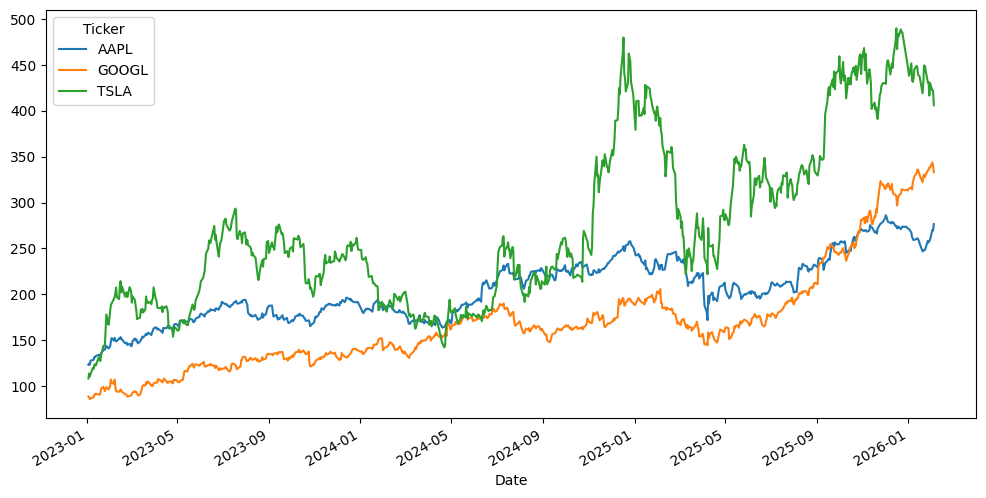

In [38]:
stocks = ["AAPL", "TSLA", "GOOGL"]
df = yf.download(stocks, start="2023-01-01")["Close"]
df.plot(figsize=(12,6))


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

data['Date'] = data.index.map(pd.Timestamp.toordinal)
X = data[['Date']]
y = data['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)


In [40]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, pred)
mse = mean_squared_error(y_test, pred)

print("R2 Score:", r2)
print("MSE:", mse)


R2 Score: 0.1547494348505598
MSE: 2854.0033983731273


In [41]:
import plotly.express as px

# Flattening y_test and pred to 1D to avoid the MultiIndex/2D array error
results = pd.DataFrame({
    "Actual": y_test.values.flatten(),
    "Predicted": pred.flatten()
})

fig = px.scatter(results, x="Actual", y="Predicted", title="Actual vs Predicted")
fig.show()

In [42]:
test_df = pd.DataFrame({
    "Date": X_test.index,
    "Actual": y_test.values.flatten(),
    "Predicted": pred.flatten()
})

fig = go.Figure()
fig.add_trace(go.Scatter(x=test_df["Date"], y=test_df["Actual"], name="Actual"))
fig.add_trace(go.Scatter(x=test_df["Date"], y=test_df["Predicted"], name="Predicted"))

fig.update_layout(title="Stock Price Prediction (Linear Regression)")
fig.show()